# DSCOVER - CatBoost


### 특징
- 수치형 변수: 원본 그대로 사용 (StandardScaler / MinMaxScaler / log 변환 없음)
- 수치형 결측치: CatBoost가 직접 처리
- 범주형 변수: **One-Hot Encoding 없이 원래 범주형으로 전달**
- 범주형 결측치: `'Missing'`이라는 별도 category로 처리
- 클래스 불균형: `auto_class_weights='Balanced'`
- 평가지표: Kaggle 기준에 맞춰 `Balanced Accuracy`를 sklearn으로 계산
- 검증: 기존 RF와 동일하게 `stratify=y`, `random_state=42`


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e7')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s6e7


## 1. 라이브러리

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)


In [ ]:
TARGET = 'health_condition'

train = pd.read_csv(
    '/kaggle/input/playground-series-s6e7/train.csv'
)

test = pd.read_csv(
    '/kaggle/input/playground-series-s6e7/test.csv'
)

sample_submission = pd.read_csv(
    '/kaggle/input/playground-series-s6e7/sample_submission.csv'
)

print("train:", train.shape)
print("test :", test.shape)

display(train.head())


Train path: /kaggle/input/competitions/playground-series-s6e7/train.csv
Test path : /kaggle/input/competitions/playground-series-s6e7/test.csv
train: (690088, 15)
test : (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 3. X / y 설정

In [ ]:
X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()

X_test = test.copy()

# id는 식별자이므로 학습 feature에서 제거
drop_cols = []

if 'id' in X.columns:
    drop_cols.append('id')

X = X.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("X shape     :", X.shape)
print("X_test shape:", X_test.shape)
print("y shape     :", y.shape)


X shape     : (690088, 13)
X_test shape: (295753, 13)
y shape     : (690088,)


## 4. 범주형 / 수치형 컬럼 확인

CatBoost - 범주형을 One-Hot Encoding하지 않음

수치형은 크기 범위가 서로 달라도 그대로 사용


In [ ]:
numeric_cols = X.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numeric features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)


Numeric features:
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Categorical features:
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


### 범주형 결측치 처리

CatBoost - 수치형 NaN 직접 처리 가능

범주형 결측치 - `Missing`이라는 별도의 category로 변경


In [ ]:
for col in categorical_cols:
    X[col] = X[col].where(X[col].notna(), 'Missing').astype(str)
    X_test[col] = X_test[col].where(X_test[col].notna(), 'Missing').astype(str)

print("Numeric missing :", X[numeric_cols].isna().sum().sum())
print("Category missing:", X[categorical_cols].isna().sum().sum())


Numeric missing : 214877
Category missing: 0


## 5. Train / Validation Split

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

print("\n전체 target 비율")
print(y.value_counts(normalize=True))

print("\nTrain target 비율")
print(y_train.value_counts(normalize=True))

print("\nValid target 비율")
print(y_valid.value_counts(normalize=True))


Train: (552070, 13)
Valid: (138018, 13)

전체 target 비율
health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64

Train target 비율
health_condition
at-risk      0.858676
unhealthy    0.083647
fit          0.057677
Name: proportion, dtype: float64

Valid target 비율
health_condition
at-risk      0.858671
unhealthy    0.083649
fit          0.057681
Name: proportion, dtype: float64


## 6. CatBoost Baseline

원본 변수 사용

RandomForest의 `balanced_subsample`과 비슷한 목적에서 `auto_class_weights='Balanced'`를 적용합니다.

`eval_metric='MultiClass'`는 early stopping용이고, 최종 비교 점수는 아래에서 직접 `Balanced Accuracy`로 계산합니다.


In [ ]:
cat_model = CatBoostClassifier(
    iterations=700,
    depth=7,
    learning_rate=0.08,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
    thread_count=-1
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=80,
    use_best_model=True
)


0:	learn: 0.9808581	test: 0.9806415	best: 0.9806415 (0)	total: 1.48s	remaining: 17m 12s
100:	learn: 0.1776725	test: 0.1804520	best: 0.1804520 (100)	total: 2m 4s	remaining: 12m 21s
200:	learn: 0.1695864	test: 0.1766378	best: 0.1766378 (200)	total: 4m 15s	remaining: 10m 33s
300:	learn: 0.1639611	test: 0.1752453	best: 0.1752381 (299)	total: 6m 37s	remaining: 8m 47s
400:	learn: 0.1590187	test: 0.1745664	best: 0.1745573 (396)	total: 9m	remaining: 6m 42s
500:	learn: 0.1543122	test: 0.1741914	best: 0.1741914 (500)	total: 11m 23s	remaining: 4m 31s
600:	learn: 0.1504838	test: 0.1741540	best: 0.1740616 (568)	total: 13m 45s	remaining: 2m 15s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.1740615652
bestIteration = 568

Shrink model to first 569 iterations.


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=7, eval_metric='MultiClass', iterations=700, learning_rate=0.08, loss_function='MultiClass', random_seed=42, verbose=100)

## 7. Validation 성능

In [ ]:
valid_pred = cat_model.predict(X_valid).reshape(-1)

accuracy = accuracy_score(y_valid, valid_pred)
balanced_acc = balanced_accuracy_score(y_valid, valid_pred)

print(f"Accuracy          : {accuracy:.5f}")
print(f"Balanced Accuracy : {balanced_acc:.5f}")

print("\nRF Baseline BA        : 0.85028")
print("RF + Threshold FE BA  : 0.85135")
print(f"CatBoost BA            : {balanced_acc:.5f}")
print(f"vs RF Baseline         : {balanced_acc - 0.85028:+.5f}")
print(f"vs RF Threshold FE     : {balanced_acc - 0.85135:+.5f}")


Accuracy          : 0.93829
Balanced Accuracy : 0.94967

RF Baseline BA        : 0.85028
RF + Threshold FE BA  : 0.85135
CatBoost BA            : 0.94967
vs RF Baseline         : +0.09939
vs RF Threshold FE     : +0.09832


In [ ]:
print(
    classification_report(
        y_valid,
        valid_pred,
        digits=4
    )
)


              precision    recall  f1-score   support

     at-risk     0.9937    0.9350    0.9634    118512
         fit     0.7346    0.9486    0.8280      7961
   unhealthy     0.6869    0.9654    0.8027     11545

    accuracy                         0.9383    138018
   macro avg     0.8050    0.9497    0.8647    138018
weighted avg     0.9531    0.9383    0.9422    138018



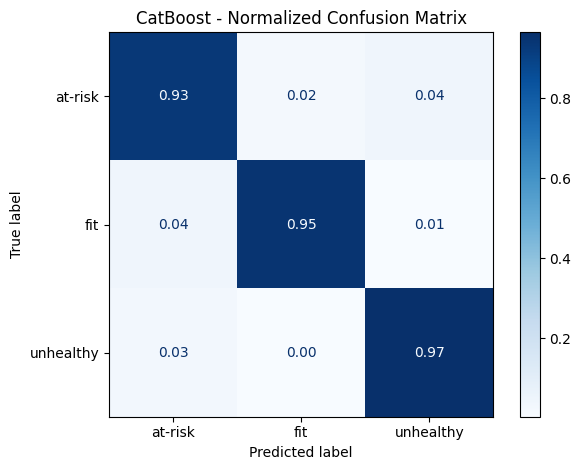

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_pred,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)

plt.title('CatBoost - Normalized Confusion Matrix')
plt.tight_layout()
plt.show()


## 8. CatBoost Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': cat_model.get_feature_importance()
}).sort_values(
    'importance',
    ascending=False
).reset_index(drop=True)

display(feature_importance)


,feature,importance
0,stress_level,32.156488
1,sleep_duration,24.585546
2,bmi,10.639228
3,physical_activity_level,10.206100
4,exercise_duration,4.166945
5,step_count,3.678235
6,water_intake,3.044566
7,heart_rate,2.915488
8,smoking_alcohol,2.732772
9,calorie_expenditure,2.307809


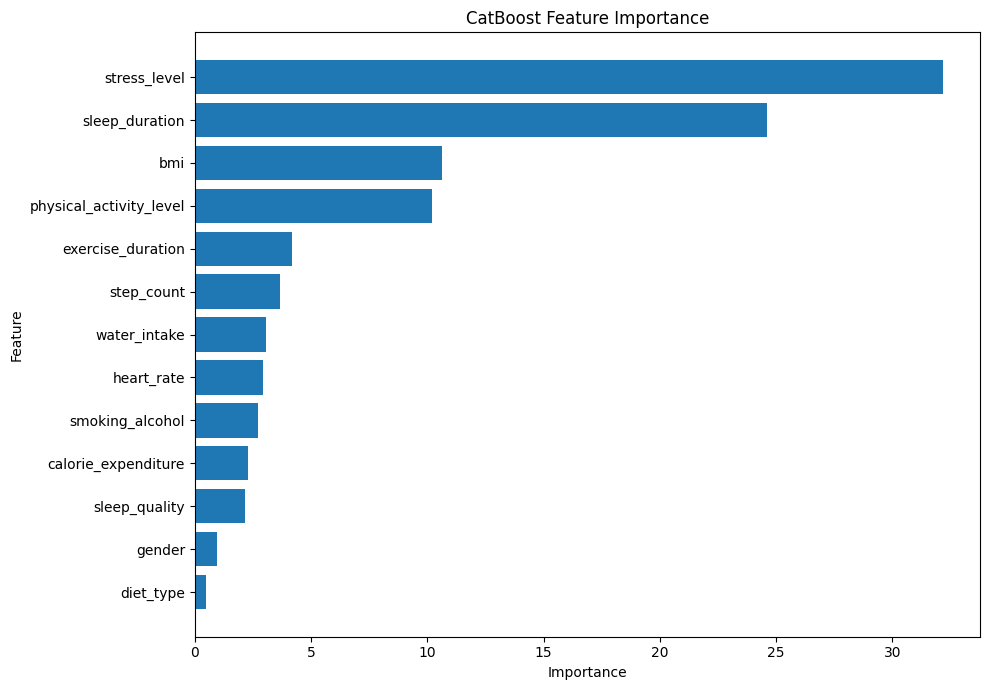

In [ ]:
top_n = min(20, len(feature_importance))

top_features = (
    feature_importance
    .head(top_n)
    .sort_values('importance', ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


## 9. 현재 병목 확인

- `at-risk 0.50 / fit 0.46`처럼 가깝다면 → class weight / threshold 조정 가능성이 큼
- `at-risk 0.90 / fit 0.07`처럼 멀다면 → feature interaction / 모델 표현력 문제 가능성이 큼


In [ ]:
valid_proba = cat_model.predict_proba(X_valid)
class_names = cat_model.classes_

proba_df = pd.DataFrame(
    valid_proba,
    columns=class_names,
    index=X_valid.index
)

proba_df['true'] = y_valid
proba_df['pred'] = valid_pred

fit_to_risk = proba_df[
    (proba_df['true'] == 'fit') &
    (proba_df['pred'] == 'at-risk')
].copy()

unhealthy_to_risk = proba_df[
    (proba_df['true'] == 'unhealthy') &
    (proba_df['pred'] == 'at-risk')
].copy()

print("fit → at-risk 오분류 개수:", len(fit_to_risk))
print("unhealthy → at-risk 오분류 개수:", len(unhealthy_to_risk))

print("\nfit → at-risk 예측확률 평균")
display(fit_to_risk[class_names].mean().to_frame('mean_probability'))

print("\nunhealthy → at-risk 예측확률 평균")
display(unhealthy_to_risk[class_names].mean().to_frame('mean_probability'))


fit → at-risk 오분류 개수: 356
unhealthy → at-risk 오분류 개수: 351

fit → at-risk 예측확률 평균


,mean_probability
at-risk,0.899285
fit,0.072365
unhealthy,0.028350



unhealthy → at-risk 예측확률 평균


,mean_probability
at-risk,0.832893
fit,0.033314
unhealthy,0.133794


In [ ]:
# 실제 fit인데 at-risk로 틀린 샘플 중
# at-risk와 fit 확률이 가장 가까운 경계 샘플 확인

if len(fit_to_risk) > 0:
    tmp = fit_to_risk.copy()
    tmp['gap'] = (
        tmp['at-risk'] - tmp['fit']
    ).abs()

    display(
        tmp.sort_values('gap')
           .head(20)
    )


,at-risk,fit,unhealthy,true,pred,gap
570622,0.501132,0.409950,0.088919,fit,at-risk,0.091182
525939,0.567878,0.416886,0.015237,fit,at-risk,0.150992
314550,0.585481,0.411626,0.002893,fit,at-risk,0.173856
585315,0.594142,0.390882,0.014976,fit,at-risk,0.203260
335220,0.598859,0.390557,0.010584,fit,at-risk,0.208302
387508,0.543018,0.323309,0.133673,fit,at-risk,0.219708
153117,0.531917,0.247834,0.220249,fit,at-risk,0.284084
587474,0.622970,0.338324,0.038706,fit,at-risk,0.284645
88855,0.660511,0.335374,0.004115,fit,at-risk,0.325137
595001,0.676037,0.322479,0.001484,fit,at-risk,0.353558


In [ ]:
# 실제 unhealthy인데 at-risk로 틀린 샘플 중
# at-risk와 unhealthy 확률이 가장 가까운 경계 샘플 확인

if len(unhealthy_to_risk) > 0:
    tmp = unhealthy_to_risk.copy()
    tmp['gap'] = (
        tmp['at-risk'] - tmp['unhealthy']
    ).abs()

    display(
        tmp.sort_values('gap')
           .head(20)
    )


,at-risk,fit,unhealthy,true,pred,gap
40741,0.499043,0.013960,0.486997,unhealthy,at-risk,0.012046
15779,0.498008,0.016045,0.485947,unhealthy,at-risk,0.012061
193606,0.501448,0.009592,0.488959,unhealthy,at-risk,0.012489
600646,0.493286,0.026027,0.480687,unhealthy,at-risk,0.012599
911,0.508527,0.002653,0.488820,unhealthy,at-risk,0.019706
582971,0.481834,0.056515,0.461651,unhealthy,at-risk,0.020182
40026,0.493996,0.033727,0.472276,unhealthy,at-risk,0.021720
586003,0.502240,0.017778,0.479982,unhealthy,at-risk,0.022258
563595,0.496858,0.030960,0.472183,unhealthy,at-risk,0.024675
201071,0.498147,0.029779,0.472074,unhealthy,at-risk,0.026073


## 10. 전체 Train 재학습 후 Test 예측

Validation 결과가 RF보다 의미 있게 좋을 때 실행합니다. (기존에 Randomforest 실행해봄)

`best_iteration_`을 사용해 validation에서 찾은 적정 반복 횟수로 전체 train을 다시 학습합니다.


In [ ]:
best_iterations = cat_model.get_best_iteration()

# get_best_iteration()이 0-based이므로 +1
if best_iterations is None or best_iterations < 0:
    best_iterations = 700
else:
    best_iterations += 1

print("Best iterations:", best_iterations)

final_model = CatBoostClassifier(
    iterations=best_iterations,
    depth=7,
    learning_rate=0.08,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
    thread_count=-1
)

final_model.fit(
    X,
    y,
    cat_features=categorical_cols
)


Best iterations: 569
0:	learn: 0.9803340	total: 1.54s	remaining: 14m 33s
100:	learn: 0.1780095	total: 2m 31s	remaining: 11m 42s
200:	learn: 0.1712302	total: 4m 53s	remaining: 8m 56s
300:	learn: 0.1658381	total: 7m 41s	remaining: 6m 51s
400:	learn: 0.1614383	total: 10m 30s	remaining: 4m 24s
500:	learn: 0.1577196	total: 13m 19s	remaining: 1m 48s
568:	learn: 0.1551203	total: 15m 14s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=7, iterations=569, learning_rate=0.08, loss_function='MultiClass', random_seed=42, verbose=100)

In [ ]:
test_pred = final_model.predict(X_test).reshape(-1)

print(
    pd.Series(test_pred)
      .value_counts(normalize=True)
)


at-risk      0.809902
unhealthy    0.115843
fit          0.074255
Name: proportion, dtype: float64


## 11. Submission

In [ ]:
submission = sample_submission.copy()
submission[TARGET] = test_pred

display(submission.head())

print(submission.shape)
print(submission[TARGET].value_counts())


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


(295753, 2)
health_condition
at-risk      239531
unhealthy     34261
fit           21961
Name: count, dtype: int64


In [ ]:
submission.to_csv(
    'submission_catboost_baseline.csv',
    index=False
)

print("Saved: submission_catboost_baseline.csv")


Saved: submission_catboost_baseline.csv


## 12. 실험 결과 기록

In [ ]:
experiment_results = pd.DataFrame({
    'experiment': [
        'RF Baseline',
        'RF + Threshold FE',
        'CatBoost Baseline'
    ],
    'balanced_accuracy': [
        0.85028,
        0.85135,
        balanced_acc
    ]
})

experiment_results['delta_vs_rf'] = (
    experiment_results['balanced_accuracy'] - 0.85028
)

display(experiment_results)


,experiment,balanced_accuracy,delta_vs_rf
0,RF Baseline,0.850280,0.000000
1,RF + Threshold FE,0.851350,0.001070
2,CatBoost Baseline,0.949672,0.099392


### 다음 판단 기준

1. CatBoost BA가 RF보다 확실히 높음  
   → CatBoost를 기준 모델로 전환

2. BA는 비슷하지만 `fit`, `unhealthy` recall이 개선됨  
   → CatBoost에서 class weight / probability threshold 추가 실험

3. RF와 거의 동일  
   → `sleep × stress`, `sleep × activity`, `stress × activity` 등 2차 interaction EDA 후 FE 또는 2-stage classifier 검토

4. 단일 validation 차이가 작음  
   → 최종 판단 전 Stratified K-Fold CV로 확인
